# Лабораторная работа 2. Обучение с учителем. Задача регрессии

## Задача регрессии

### Загрузка данных

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('../datasets/filtered_moldova_cars_task.csv')
data

,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Price(euro),Vehicle_age,Avg_mileage
0,0.102058,0.011583,2011,0.186425,195000,1800,0.054398,0.381082,7750,15,13000
1,0.084965,0.012745,2014,0.206439,135000,1500,0.466976,0.618918,8550,12,11250
2,0.118254,0.027315,1998,0.186425,1,1400,0.358679,0.618918,2200,28,0
3,0.084965,0.004016,2012,0.206439,110000,1500,0.466976,0.618918,6550,14,7857
4,0.067707,0.030501,2006,0.206439,200000,1600,0.107202,0.618918,4100,20,10000
...,...,...,...,...,...,...,...,...,...,...,...
30125,0.005012,0.002622,2002,0.110289,225000,1800,0.107202,0.618918,4400,24,9375
30126,0.048623,0.017126,2015,0.206439,89000,1500,0.466976,0.618918,7000,11,8091
30127,0.084965,0.000431,2009,0.186425,225,1500,0.466976,0.618918,4500,17,13
30128,0.015500,0.002987,2006,0.011650,370000,2000,0.466976,0.618918,4000,20,18500


### Первый шаг: выделение целевого признака и предикторов

In [3]:
y = data["Price(euro)"]
X = data.drop(["Price(euro)"], axis=1)

In [4]:
y

0        7750
1        8550
2        2200
3        6550
4        4100
         ... 
30125    4400
30126    7000
30127    4500
30128    4000
30129    4000
Name: Price(euro), Length: 30130, dtype: int64

In [5]:
X

,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Vehicle_age,Avg_mileage
0,0.102058,0.011583,2011,0.186425,195000,1800,0.054398,0.381082,15,13000
1,0.084965,0.012745,2014,0.206439,135000,1500,0.466976,0.618918,12,11250
2,0.118254,0.027315,1998,0.186425,1,1400,0.358679,0.618918,28,0
3,0.084965,0.004016,2012,0.206439,110000,1500,0.466976,0.618918,14,7857
4,0.067707,0.030501,2006,0.206439,200000,1600,0.107202,0.618918,20,10000
...,...,...,...,...,...,...,...,...,...,...
30125,0.005012,0.002622,2002,0.110289,225000,1800,0.107202,0.618918,24,9375
30126,0.048623,0.017126,2015,0.206439,89000,1500,0.466976,0.618918,11,8091
30127,0.084965,0.000431,2009,0.186425,225,1500,0.466976,0.618918,17,13
30128,0.015500,0.002987,2006,0.011650,370000,2000,0.466976,0.618918,20,18500


### Разбиение на обучающую и тестовую выборки

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [7]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((24104, 10), (24104,), (6026, 10), (6026,))

### Линейная регрессия в sklearn (+ регуляризации и использование полиномов)

In [8]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from math import sqrt

In [9]:
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)


In [10]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')
print(f'R^2: {r2_score(y_test, y_pred)}')
lr.coef_

MAE: 2243.9611088345864
MSE: 9358656.306021836
RMSE: 3059.1921002156496
MAPE: 0.5798649036578467
R^2: 0.6588392643004041


array([-1.39927944e+03,  8.96748244e+03,  1.94927045e+02, -1.70445195e+03,
       -1.51730673e-02,  4.14312377e+00,  3.57738077e+02, -9.84403698e+03,
       -1.94927045e+02,  2.49108661e-01])

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

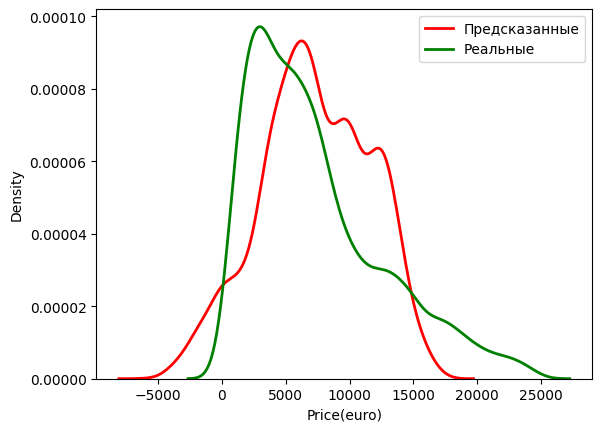

In [12]:
sns.kdeplot(y_pred, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
# L1
lasso = Lasso(alpha=0.5, max_iter=50000).fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
print(f'MAE: {mean_absolute_error(y_test, y_pred_lasso)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_lasso)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred_lasso))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred_lasso)}')
print(f'R^2: {r2_score(y_test, y_pred_lasso)}')
lasso.coef_

MAE: 2243.951818419643
MSE: 9358735.095956732
RMSE: 3059.204977760845
MAPE: 0.5798134826727517
R^2: 0.6588363920897709


array([  -47.38678154,    91.28933559,  2627.87633397,  -142.27722045,
       -1461.09922937,  1516.81159821,    48.77897606, -1137.45756524,
          -0.        ,  1353.82305064])

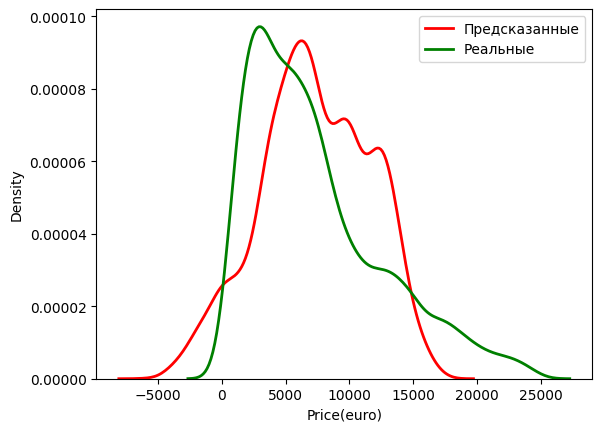

In [15]:
sns.kdeplot(y_pred_lasso, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

In [16]:
# L2
ridge = Ridge(alpha=0.5, max_iter=50000).fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
print(f'MAE: {mean_absolute_error(y_test, y_pred_ridge)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_ridge)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred_ridge))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred_ridge)}')
print(f'R^2: {r2_score(y_test, y_pred_ridge)}')
ridge.coef_

MAE: 2243.9615158983224
MSE: 9358668.143390017
RMSE: 3059.194034936329
MAPE: 0.5798634402083092
R^2: 0.6588388327806318


array([  -48.35455695,    92.4227898 ,  1312.80544347,  -142.94348335,
       -1465.91115173,  1517.34259372,    49.10855013, -1137.69733082,
       -1312.8054435 ,  1358.57282859])

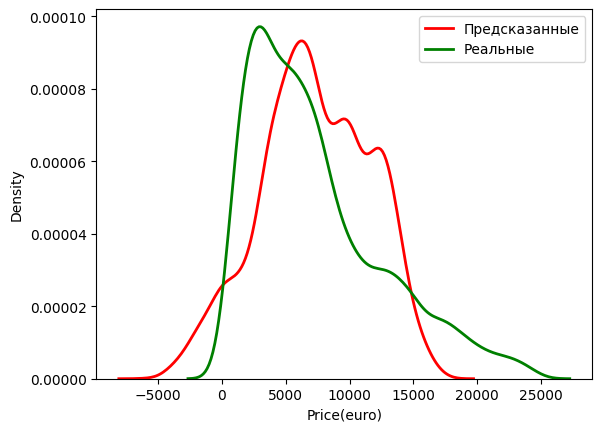

In [17]:
sns.kdeplot(y_pred_ridge, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

In [18]:
el = ElasticNet(alpha=0.5, max_iter=50000).fit(X_train_scaled, y_train)
y_pred_el = el.predict(X_test_scaled)
print(f'MAE: {mean_absolute_error(y_test, y_pred_el)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_el)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred_el))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred_el)}')
print(f'R^2: {r2_score(y_test, y_pred_el)}')
el.coef_

MAE: 2275.3075753341523
MSE: 9686576.056291131
RMSE: 3112.3264700688346
MAPE: 0.5545049284841261
R^2: 0.6468852679579681


array([  -44.61963017,    53.38981836,  1345.08859859,  -153.67344587,
        -626.96568086,  1157.02627056,    47.35099228, -1124.21234111,
       -1345.00257878,   563.58854528])

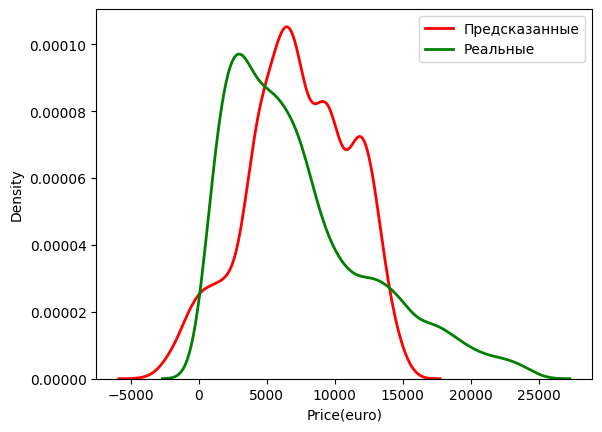

In [19]:
sns.kdeplot(y_pred_el, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

In [20]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_p = poly.fit_transform(X_train_scaled)
X_test_p = poly.transform(X_test_scaled)
lr2 = LinearRegression().fit(X_train_p, y_train)
y_pred_p = lr2.predict(X_test_p)
print(f'MAE: {mean_absolute_error(y_test, y_pred_p)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_p)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred_p))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred_p)}')
print(f'R^2: {r2_score(y_test, y_pred_p)}')
lr2.coef_

MAE: 1712.564923322794
MSE: 5883294.782591467
RMSE: 2425.550408173672
MAPE: 0.4009931893516538
R^2: 0.7855301967788905


array([-1.44569320e+02,  3.79060963e+02, -2.83967119e+04, -1.42095852e+02,
       -9.00319742e+04,  1.58054511e+03,  1.34846545e+02, -5.49289082e+02,
        2.83967119e+04,  9.08262712e+04,  1.00379505e+02, -3.28049484e+02,
        4.81465311e+01, -5.15136193e+01,  3.39722850e+02, -7.88331999e+01,
       -3.58274797e+01,  1.24557068e+02, -4.81465311e+01, -3.33961543e+02,
       -1.03979316e+01,  8.62218568e+01,  2.05611152e+02, -5.39698013e+00,
       -1.04048583e+01, -6.20365206e+01,  4.04704250e+01, -8.62218570e+01,
        2.01739323e+00,  4.05642485e+02, -8.36409825e+01,  2.51640176e+02,
        2.91090003e+02,  6.89509647e+01, -3.00405990e+02, -4.05642484e+02,
       -1.72713227e+04,  6.37641683e+01, -2.54226869e+01, -2.21060843e+01,
        9.96123901e+01, -4.52802045e+00,  8.36409824e+01,  7.79177518e+01,
        4.59062530e+02, -5.13999591e+02, -2.10087625e+02,  4.40965999e+01,
       -2.51640176e+02, -6.48705836e+02,  6.28274697e-01,  1.20852664e+02,
       -1.35416405e+02, -

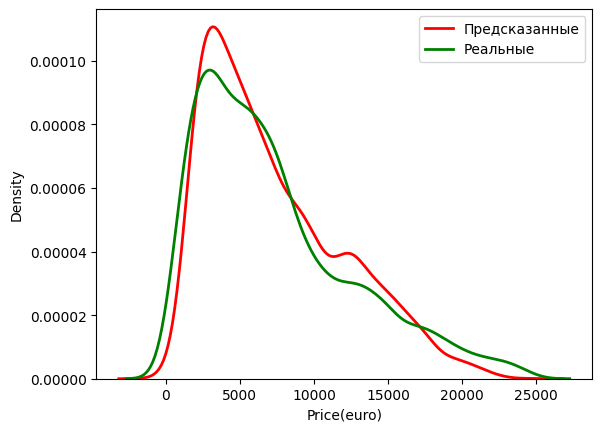

In [21]:
sns.kdeplot(y_pred_p, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

# Поиск оптимального гиперпараметра для моделей 

In [22]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

In [23]:
parameters = {'alpha': np.arange(0.1, 10.1, 0.1)}

In [24]:
lasso_optimal = GridSearchCV(Lasso(max_iter = 10000), parameters, cv=5).fit(X_train_scaled, y_train)
lasso_optimal.best_params_

{'alpha': np.float64(0.1)}

In [25]:
lasso_optimal = RandomizedSearchCV(Lasso(max_iter = 10000), parameters, cv=5).fit(X_train_scaled, y_train)
lasso_optimal.best_params_

{'alpha': np.float64(1.2000000000000002)}

In [26]:
ridge_optimal = GridSearchCV(Ridge(max_iter = 10000), parameters, cv=5).fit(X_train_scaled, y_train)
ridge_optimal.best_params_

{'alpha': np.float64(10.0)}

In [27]:
ridge_optimal = RandomizedSearchCV(Ridge(max_iter = 10000), parameters, cv=5).fit(X_train_scaled, y_train)
ridge_optimal.best_params_

{'alpha': np.float64(9.4)}

In [28]:
parameters = {'alpha': np.arange(0.1, 10.1, 0.1), 'l1_ratio': np.arange(0.1, 1.1, 0.1)}

In [29]:
el_optimal = GridSearchCV(ElasticNet(max_iter = 10000), parameters, cv=5).fit(X_train_scaled, y_train)
el_optimal.best_params_

{'alpha': np.float64(0.1), 'l1_ratio': np.float64(1.0)}

In [30]:
el_optimal = RandomizedSearchCV(ElasticNet(max_iter = 10000), parameters, cv=5).fit(X_train_scaled, y_train)
el_optimal.best_params_

{'l1_ratio': np.float64(0.7000000000000001), 'alpha': np.float64(0.1)}

In [31]:
import optuna as pt

def optuna(model_name, X_train, y_train, X_test, y_test):
    def objective(trial):
        alpha = trial.suggest_float("alpha", 1e-5, 1e2)

        if model_name == 'lasso':
            model = Lasso(alpha=alpha)
        elif model_name == 'ridge':
            model = Ridge(alpha=alpha)
        elif model_name == 'elasticnet':
            l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
            model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        return mse
    
    # Настраиваем оптимизацию гиперпараметров
    study = pt.create_study(direction='minimize')
    study.optimize(objective, n_trials=100)

    # Выводим лучшие гиперпараметры
    best_params = study.best_params
    
    return best_params['alpha'] if model_name != 'elasticnet' else (best_params['alpha'], best_params['l1_ratio'])


c:\Users\arau7\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
models = ('lasso', 'ridge', 'elasticnet')
best_params = {}

for model in models:
    best_param = optuna(model, X_train=X_train_scaled, y_train=y_train, X_test=X_test_scaled, y_test=y_test)
    best_params[f'{model}_optuna'] = best_param

[I 2025-09-16 08:53:28,644] A new study created in memory with name: no-name-f2efaa95-50ca-457a-95d3-292e71a51145
[I 2025-09-16 08:53:28,727] Trial 0 finished with value: 9445712.87790096 and parameters: {'alpha': 60.39967783814667}. Best is trial 0 with value: 9445712.87790096.
[I 2025-09-16 08:53:28,763] Trial 1 finished with value: 9397472.326707419 and parameters: {'alpha': 38.553737936821946}. Best is trial 1 with value: 9397472.326707419.
[I 2025-09-16 08:53:28,788] Trial 2 finished with value: 9473795.678203868 and parameters: {'alpha': 70.65614158613938}. Best is trial 1 with value: 9397472.326707419.
[I 2025-09-16 08:53:28,809] Trial 3 finished with value: 9454033.03143527 and parameters: {'alpha': 63.588962058766036}. Best is trial 1 with value: 9397472.326707419.
[I 2025-09-16 08:53:28,830] Trial 4 finished with value: 9473568.523116838 and parameters: {'alpha': 70.57785221631583}. Best is trial 1 with value: 9397472.326707419.
[I 2025-09-16 08:53:28,847] Trial 5 finished wi

In [33]:
for model in models:
    print(f"Лучший параметр для {model}: {best_params[f'{model}_optuna']}")

Лучший параметр для lasso: 0.011109949921541684
Лучший параметр для ridge: 0.00010505953483797015
Лучший параметр для elasticnet: (0.08426564092015276, 0.9999123494842947)


# Построение pipelines

Нам осталось разобраться с полиномиальной регрессией. Ее проще всего понять на одномерной регрессии (когда у нас один предиктор). Давайте создадим искусственный датасет, в котором у нас будет зарплата специалиста и его стаж. Мы хотим построить модель, которая будет предсказывать зарплату по стажу.

In [34]:
data2=pd.DataFrame({
    'Exp':[2,2.2, 2.8, 4, 7, 8, 11, 12, 21, 25],
    'Salary': [7, 8, 11, 15, 22, 29, 37 ,45.7, 49, 52]
})
data2

,Exp,Salary
0,2.0,7.0
1,2.2,8.0
2,2.8,11.0
3,4.0,15.0
4,7.0,22.0
5,8.0,29.0
6,11.0,37.0
7,12.0,45.7
8,21.0,49.0
9,25.0,52.0


Выделим целевой признак и предиктор

In [35]:
y = data2['Salary'].values.reshape(-1,1)
# reshape здесь чисто технический, т. к. ожидается двумерный массив, а у нас 1 предиктор
X = data2['Exp'].values.reshape(-1,1)

In [36]:
lr = LinearRegression().fit(X, y)
lr.coef_

array([[2.04404542]])

Если мы будем строить модель линейной регрессии, то в процессе обучения будет изменяться только одна переменная - это вес единственного предиктора. <b>Суть полиномиальной регрессии - мы добавляем новые предикторы и используем ту же модель линейной регрессии.</b> Давайте сделаем регрессию со степенью полинома 2.

In [37]:
from sklearn.preprocessing import PolynomialFeatures
# создаем объект, который позволит расширить множество предикторов
p = PolynomialFeatures(2)
# добавляем новые предикторы
X_p=p.fit_transform(X)
X_p

array([[  1.  ,   2.  ,   4.  ],
       [  1.  ,   2.2 ,   4.84],
       [  1.  ,   2.8 ,   7.84],
       [  1.  ,   4.  ,  16.  ],
       [  1.  ,   7.  ,  49.  ],
       [  1.  ,   8.  ,  64.  ],
       [  1.  ,  11.  , 121.  ],
       [  1.  ,  12.  , 144.  ],
       [  1.  ,  21.  , 441.  ],
       [  1.  ,  25.  , 625.  ]])

Посмотрите. Вместо одного предиктора у нас теперь их 3. При этом один из них имеет единственное значение (1), двугой - это исходный предиктор, а третий - это его квадрат. То есть теперь, если мы будем решать задачу линейной регрессии для такого множества предикторов, то мы будем приближать значения y уже не линейно, а квадратично! По сути мы будем подбирать коэффициенты $a$, $b$ и $c$ уравнения $\hat{y_i}=aX_{i}^2+bX_{i}+c$.

In [38]:
lr2 = LinearRegression().fit(X_p, y)
lr2.coef_

array([[ 0.        ,  4.89528546, -0.11005039]])

Давайте немного порисуем, чтобы увидеть :)

In [39]:
X_d = X
y_d = lr2.coef_[0][2] + lr2.coef_[0][1]*X_d + lr2.coef_[0][0]*X_d**2
y_d

array([[  9.68052054],
       [ 10.65957763],
       [ 13.59674891],
       [ 19.47109146],
       [ 34.15694785],
       [ 39.05223332],
       [ 53.73808971],
       [ 58.63337517],
       [102.69094434],
       [122.2720862 ]])

In [40]:
import matplotlib.pyplot as plt

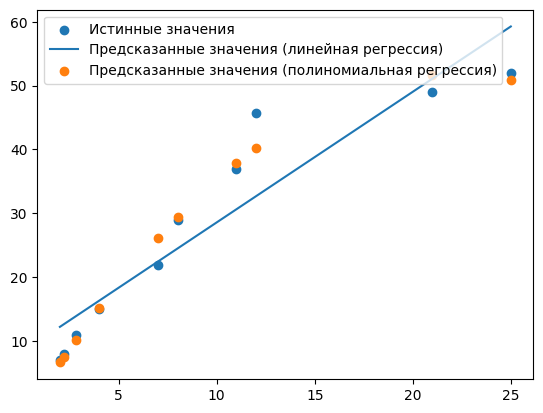

In [41]:
plt.scatter(X, y, label='Истинные значения');
plt.plot(X, lr.predict(X), label='Предсказанные значения (линейная регрессия)');
plt.scatter(X, lr2.predict(X_p), label='Предсказанные значения (полиномиальная регрессия)');
plt.legend();

Если у нас было бы несколько предикторов, то преобразование PolynomialFeatures позволило бы получить все возможные комбинации степеней. Кстати, никто не запрещает нам использовать полиномы более высоких степеней чем 2.

Теперь мы с вами знаем, как работает линейная и полиномиальная регрессия, умеем использовать регуляризации. <b>Поздравляю вас с началом вашего пути в ML!</b>